In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)


import gzip
import struct

def load_mnist_images(path, limit=None):
    with gzip.open(path, "rb") as fh:
        magic, count, rows, cols = struct.unpack(">IIII", fh.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number: {magic}")
        if limit is None:
            limit = count
        data = np.frombuffer(fh.read(rows * cols * limit), dtype=np.uint8)
    return data.reshape(limit, rows, cols).astype("float32") / 255.0

def load_mnist_labels(path, limit=None):
    with gzip.open(path, "rb") as fh:
        magic, count = struct.unpack(">II", fh.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number: {magic}")
        if limit is None:
            limit = count
        return np.frombuffer(fh.read(limit), dtype=np.uint8)

In [2]:
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

tf.random.set_seed(RANDOM_STATE)

train_images = load_mnist_images(DATA_DIR / "mnist/train-images-idx3-ubyte.gz", limit=8000)
train_labels = load_mnist_labels(DATA_DIR / "mnist/train-labels-idx1-ubyte.gz", limit=8000)
test_images = load_mnist_images(DATA_DIR / "mnist/t10k-images-idx3-ubyte.gz", limit=2000)
test_labels = load_mnist_labels(DATA_DIR / "mnist/t10k-labels-idx1-ubyte.gz", limit=2000)

print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)

I0000 00:00:1776648550.488690   37051 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776648550.489065   37051 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776648550.519747   37051 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(8000, 28, 28) (8000,) (2000, 28, 28) (2000,)


I0000 00:00:1776648551.227693   37051 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776648551.227916   37051 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(
    train_images,
    train_labels,
    validation_split=0.15,
    epochs=3,
    batch_size=128,
    verbose=1,
)

E0000 00:00:1776648552.033399   37051 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/3



 1/54 ━━━━━━━━━━━━━━━━━━━━ 23s 439ms/step - accuracy: 0.1016 - loss: 2.3860


32/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4309 - loss: 1.8302   


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7074 - loss: 1.0540 - val_accuracy: 0.8375 - val_loss: 0.5336


...


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8854 - loss: 0.3963 - val_accuracy: 0.8900 - val_loss: 0.3936


Epoch 3/3



 1/54 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8906 - loss: 0.3222


33/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9059 - loss: 0.3186 


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9149 - loss: 0.2986 - val_accuracy: 0.9025 - val_loss: 0.3389


Test accuracy: 0.882


              precision    recall  f1-score   support

           0       0.95      0.98      0.96       175
           1       0.92      0.98      0.95       234
           2       0.90      0.85      0.88       219
           3       0.85      0.89      0.87       207
           4       0.86      0.93      0.89       217
           5       0.86      0.89      0.87       179
           6       0.92      0.86      0.89       178
           7       0.92      0.77      0.84       205
           8       0.87      0.78      0.82       192
           9       0.80      0.88      0.84       194

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



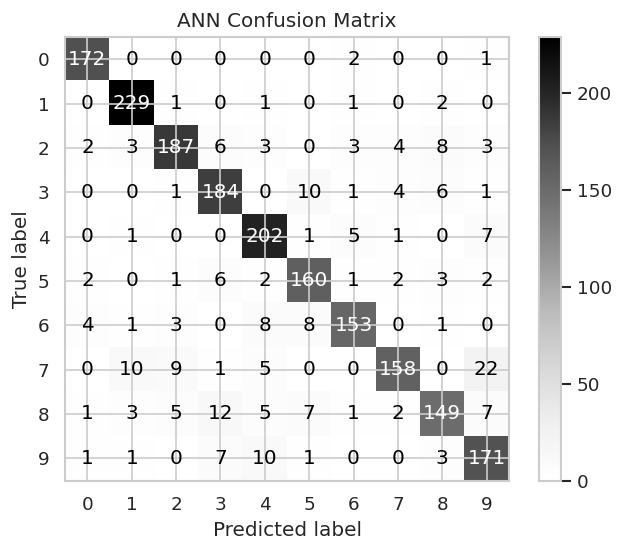

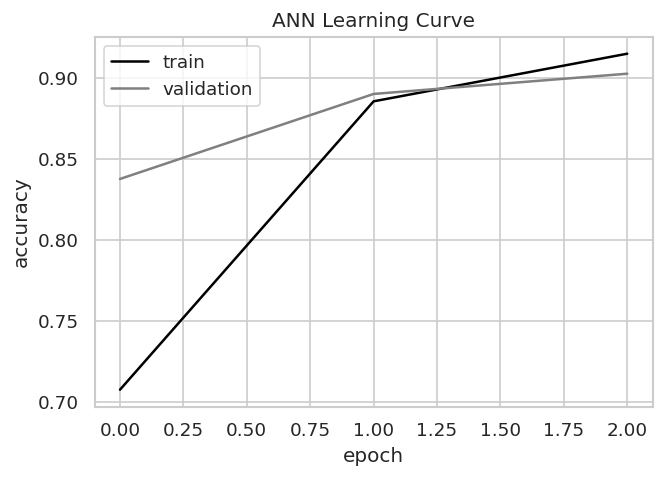

In [4]:
loss, acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {acc:.3f}")

pred = model.predict(test_images, verbose=0).argmax(axis=1)
print(classification_report(test_labels, pred))
ConfusionMatrixDisplay.from_predictions(test_labels, pred, cmap="Greys")
plt.title("ANN Confusion Matrix")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train", color="black")
plt.plot(history.history["val_accuracy"], label="validation", color="gray")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("ANN Learning Curve")
plt.legend()
plt.show()